In [10]:
!pip install pyaging

In [11]:
import pyaging as pya
import pandas as pd
import os

# Create data directory if it doesn't exist
os.makedirs('pyaging_data', exist_ok=True)

# Download and load example dataset (GSE139307 - sperm tissue methylation)
try:
    pya.data.download_example_data('GSE139307')
    df = pd.read_pickle('pyaging_data/GSE139307.pkl')
    display(df.head())
except Exception as e:
    print(f'Error loading data: {e}')

|-----> 🏗️ Starting download_example_data function
|-----------> Data found in pyaging_data/GSE139307.pkl
|-----> 🎉 Done! [0.0045s]


,dataset,tissue_type,age,gender,cg00000029,cg00000108,cg00000109,cg00000165,cg00000236,cg00000289,...,ch.X.93511680F,ch.X.938089F,ch.X.94051109R,ch.X.94260649R,ch.X.967194F,ch.X.97129969R,ch.X.97133160R,ch.X.97651759F,ch.X.97737721F,ch.X.98007042R
GSM4137709,GSE139307,sperm,84.0,M,0.084811,0.920696,0.856851,0.084567,0.838699,0.247273,...,0.061751,0.045942,0.037631,0.056455,0.249872,0.049022,0.085691,0.037435,0.077820,0.106234
GSM4137710,GSE139307,sperm,69.0,M,0.099626,0.919073,0.890024,0.115541,0.852584,0.198103,...,0.075077,0.041849,0.032573,0.089790,0.250245,0.079095,0.079756,0.046229,0.091256,0.120241
GSM4137711,GSE139307,sperm,69.0,M,0.117228,0.920276,0.894317,0.117127,0.839258,0.213410,...,0.068679,0.049515,0.058097,0.079919,0.299758,0.079305,0.089815,0.065364,0.086864,0.156005
GSM4137712,GSE139307,sperm,69.0,M,0.077096,0.910204,0.908400,0.073885,0.861615,0.163276,...,0.070091,0.033289,0.038836,0.108213,0.295428,0.050731,0.099943,0.047597,0.078480,0.107480
GSM4137713,GSE139307,sperm,67.0,M,0.063524,0.911608,0.884643,0.079877,0.864654,0.176169,...,0.082368,0.038411,0.048787,0.088631,0.316694,0.041873,0.079303,0.048823,0.089010,0.117903


(37, 485516)
count    37.00000
mean     73.00000
std       7.94425
min      65.00000
25%      67.00000
50%      69.00000
75%      80.00000
max      94.00000
Name: age, dtype: float64


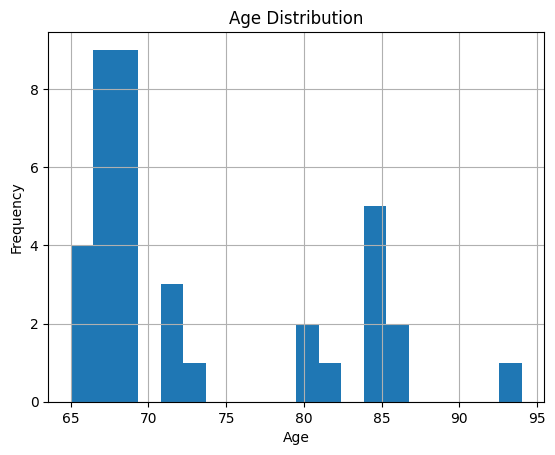

In [12]:
import matplotlib.pyplot as plt

# Dataset dimensions and age distribution summary
print(df.shape)
print(df['age'].describe())

# Plot age distribution across samples
df['age'].hist(bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [13]:
# Check sample count, feature count, and missing values
print(f"Samples: {df.shape[0]}")
print(f"Features: {df.shape[1]}")
print(f"\nMissing values in key columns:")
print(df[['age', 'tissue_type', 'gender']].isnull().sum())
print(f"\nMissing values in methylation features: {df.filter(like='cg').isnull().sum().sum()}")

Samples: 37
Features: 485516

Missing values in key columns:
age            0
tissue_type    0
gender         0
dtype: int64

Missing values in methylation features: 522


In [14]:
import numpy as np

# Extract methylation features (CpG sites)
X = df.filter(like='cg')

# Dimensionality reduction: keep top 1000 features by variance
# High-variance CpGs are more informative for age prediction
variances = X.var(axis=0)
top_features = variances.nlargest(1000).index
X = X[top_features]

print(f"Reduced X shape: {X.shape}")

# Fill missing values with column mean
X = X.fillna(X.mean())
print(f"Remaining missing values: {X.isnull().sum().sum()}")

Reduced X shape: (37, 1000)
Remaining missing values: 0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

# Define target variable
y = df['age']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ElasticNet is well-suited for high-dimensional biological data
model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} years")
print(f"R²: {r2:.3f}")

MAE: 5.81 years
R²: -0.305


In [16]:
from sklearn.model_selection import cross_val_score

# Cross-validation gives a more reliable estimate with small datasets
# 5-fold CV is appropriate for n=37
scores = cross_val_score(
    ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    X, y,
    cv=5,
    scoring='neg_mean_absolute_error'
)

print(f"MAE per fold: {-scores.round(2)}")
print(f"Mean MAE: {-scores.mean():.2f} years")
print(f"Standard deviation: {scores.std():.2f}")

MAE per fold: [4.7  6.21 6.46 7.28 7.8 ]
Mean MAE: 6.49 years
Standard deviation: 1.06


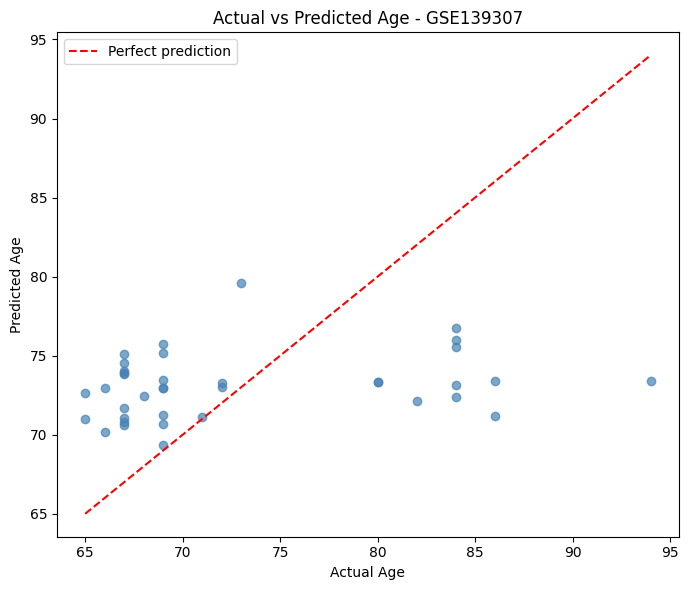

In [17]:
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions for visualization
y_pred_cv = cross_val_predict(
    ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    X, y, cv=5
)

# Scatter plot: predicted vs actual age
plt.figure(figsize=(7,6))
plt.scatter(y, y_pred_cv, alpha=0.7, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual vs Predicted Age - GSE139307')
plt.legend()
plt.tight_layout()
plt.show()